## 1. 라이브러리 불러오기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. 데이터 로딩

In [3]:
ratings = pd.read_csv("../data/books_ratings.csv")
books = pd.read_csv("../data/books.csv", low_memory=False)

print(ratings.head())
print(books.head())

   User-ID        ISBN  Book-Rating
0   276725  034545104X            0
1   276726  0155061224            5
2   276727  0446520802            0
3   276729  052165615X            3
4   276729  0521795028            6
         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                2002     Oxford University Press   
1  Richard Bruce Wright                2001       HarperFlamingo Canada   
2          Carlo D'Este                1991             HarperPerennial   
3      Gina Bari Kolata                1999        Farrar Straus Giroux   


## 3. 데이터 구조 확인

In [4]:
print(ratings.shape)
print(books.shape)

(1149780, 3)
(271360, 8)


In [5]:
print(ratings.columns)
print(books.columns)

Index(['User-ID', 'ISBN', 'Book-Rating'], dtype='object')
Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
       'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
      dtype='object')


## 4. 결측치 & 중복 확인

In [8]:
print(ratings.isnull().sum())
print(books.isnull().sum())

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64


In [16]:
books['Book-Author'].fillna("None", inplace=True)
books.drop(['Publisher', 'Image-URL-L'], axis=1, inplace=True)
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Image-URL-S            0
Image-URL-M            0
dtype: int64

In [17]:
# 중복 확인
print(ratings.duplicated().sum())
print(books.duplicated().sum())

0
0


## 5. 데이터 병합

In [20]:
books.drop(['Image-URL-S', 'Image-URL-M'], axis=1, inplace=True)
book_ratings = books.merge(ratings, on="ISBN", how="left")
print(book_ratings.head())

         ISBN           Book-Title           Book-Author Year-Of-Publication  \
0  0195153448  Classical Mythology    Mark P. O. Morford                2002   
1  0002005018         Clara Callan  Richard Bruce Wright                2001   
2  0002005018         Clara Callan  Richard Bruce Wright                2001   
3  0002005018         Clara Callan  Richard Bruce Wright                2001   
4  0002005018         Clara Callan  Richard Bruce Wright                2001   

   User-ID  Book-Rating  
0      2.0          0.0  
1      8.0          5.0  
2  11400.0          0.0  
3  11676.0          8.0  
4  41385.0          0.0  


## 6. 전체 평점 분포

In [21]:
ratings_count = ratings["Book-Rating"].value_counts().sort_index()  # sort_index() : 순서대로 정렬
print(ratings_count)

Book-Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64


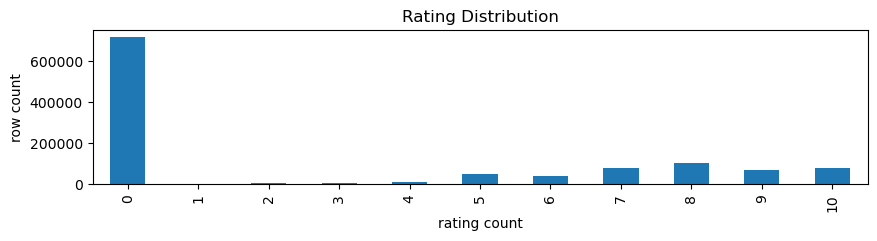

In [22]:
ratings_count.plot(kind="bar", figsize=(10, 2))
plt.title("Rating Distribution")
plt.xlabel("rating count")
plt.ylabel("row count")
plt.show()

In [23]:
# 0이 너무 많아서 제거한 버전
ratings_count0 = ratings[ratings["Book-Rating"] != 0]["Book-Rating"].value_counts().sort_index()
print(ratings_count0)

Book-Rating
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64


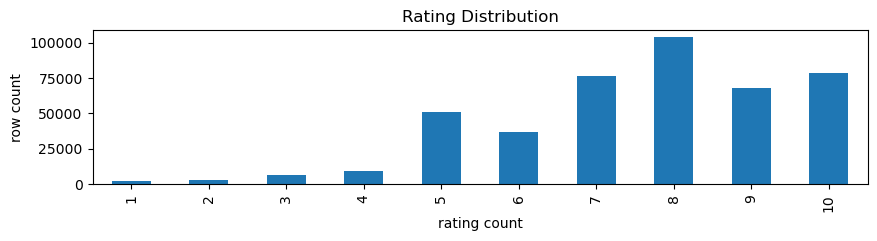

In [24]:
ratings_count0.plot(kind="bar", figsize=(10, 2))
plt.title("Rating Distribution")
plt.xlabel("rating count")
plt.ylabel("row count")
plt.show()

## 7. 사용자별 평점 개수

In [37]:
user_rating_count = ratings.groupby('User-ID').size().reset_index(name="user_rating_count")
print(user_rating_count)

        User-ID  user_rating_count
0             2                  1
1             7                  1
2             8                 18
3             9                  3
4            10                  2
...         ...                ...
105278   278846                  2
105279   278849                  4
105280   278851                 23
105281   278852                  1
105282   278854                  8

[105283 rows x 2 columns]


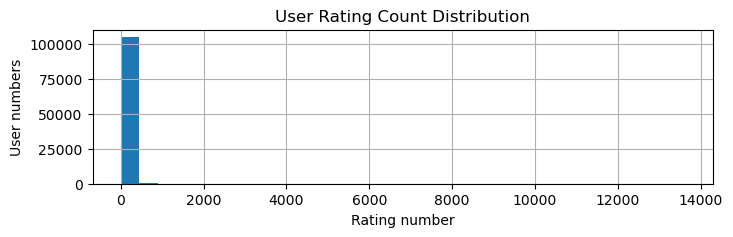

In [38]:
user_rating_count["user_rating_count"].hist(bins=30, figsize=(8,2))
plt.title("User Rating Count Distribution")
plt.xlabel("Rating number")
plt.ylabel("User numbers")
plt.show()

## 8. 책별 평점 개수 Feature 생성

In [41]:
book_rating_count = ratings.groupby('ISBN').size().reset_index(name="book_rating_count")
print(book_rating_count)

               ISBN  book_rating_count
0        0330299891                  2
1        0375404120                  2
2        0586045007                  1
3        9022906116                  2
4        9032803328                  1
...             ...                ...
340551     cn113107                  1
340552   ooo7156103                  1
340553   §423350229                  1
340554  ´3499128624                  1
340555    Ô½crosoft                  1

[340556 rows x 2 columns]
